# National & Local Early-Signal Landscape Analysis

This notebook walks through the data analysis behind the **National & Local Early-Signal Landscape Report**. We use three data sources:

- `national_pct.csv` — State-level chronic absenteeism percentages from EDFacts (2020-21 to 2022-23)
- `national_counts.csv` — State-level chronic absenteeism counts by subgroup from EDFacts
- `evaldata_cleaned.csv` — OUSD student-level longitudinal records (2017-18 to 2023-24)

**Goal:** Identify early indicators that precede chronic absenteeism, examine regional and demographic variation, and validate national patterns against OUSD student-level data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', font_scale=1.1)
palette = sns.color_palette('Set2')
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, **kw):
    fig.savefig(FIG_DIR / f'{name}.png', dpi=180, bbox_inches='tight', **kw)
    print(f'Saved {FIG_DIR / name}.png')

## 1 — Load and Prepare Data

In [2]:
# National percentage data
pct = pd.read_csv('../data/national_pct.csv')
pct['pct'] = pct['Value'].replace('MISSING', np.nan).str.rstrip('%').astype(float)
pct['Numerator'] = pd.to_numeric(pct['Numerator'], errors='coerce')
pct['Denominator'] = pd.to_numeric(pct['Denominator'], errors='coerce')

# National counts data
counts = pd.read_csv('../data/national_counts.csv')
counts['Value'] = pd.to_numeric(counts['Value'], errors='coerce')

# OUSD student-level data
ousd = pd.read_csv('../data/evaldata_cleaned.csv')
year_map = {1718:'2017-18', 1819:'2018-19', 1920:'2019-20',
            2021:'2020-21', 2122:'2021-22', 2223:'2022-23', 2324:'2023-24'}
ousd['school_year'] = ousd['year'].map(year_map)
att = ousd.dropna(subset=['AttRate']).copy()

print(f'national_pct:    {len(pct):>7,} rows')
print(f'national_counts: {len(counts):>7,} rows')
print(f'OUSD (w/ att):   {len(att):>7,} rows  ({att["ANON_ID"].nunique():,} students)')

national_pct:        162 rows
national_counts: 1,386,831 rows
OUSD (w/ att):   149,432 rows  (36,351 students)


## 2 — National Trends Over Time

In [3]:
# Build comparison table: National vs California vs OUSD
us = pct[pct['State'] == 'UNITED STATES'].set_index('School Year')['pct']
ca = pct[pct['State'] == 'CALIFORNIA'].set_index('School Year')['pct']

ousd_rates = (att.groupby('school_year')['chronic_absent']
              .mean().mul(100).rename('OUSD'))

trend = pd.DataFrame({
    'National': us,
    'California': ca,
}).rename_axis('School Year')

# Map OUSD years to match national format
ousd_yr_map = {'2020-21':'2020-2021','2021-22':'2021-2022','2022-23':'2022-2023'}
for short, long in ousd_yr_map.items():
    trend.loc[long, 'OUSD'] = ousd_rates.get(short, np.nan)

trend = trend.sort_index()
display(trend.round(1))

,National,California,OUSD
School Year,,,
2020-2021,21.1,15.4,15.8
2021-2022,30.8,33.0,40.6
2022-2023,27.8,27.7,56.3


Saved ../reports/figures/fig1_national_ca_ousd_trend.png


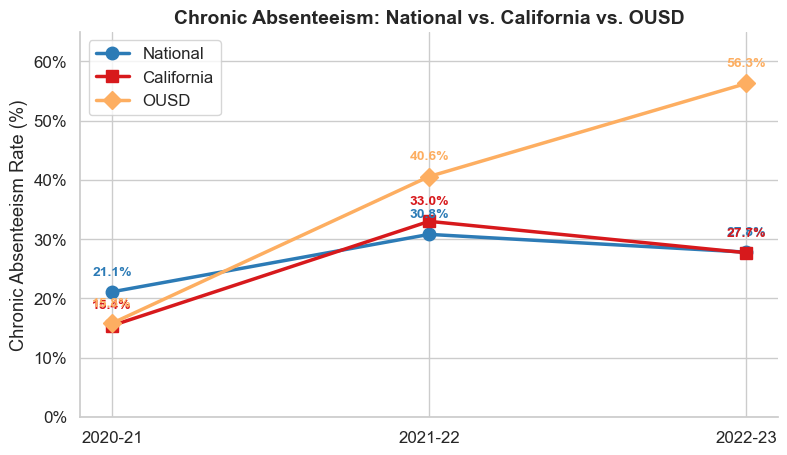

In [4]:
# --- Chart 1: National vs California vs OUSD trend lines ---
fig, ax = plt.subplots(figsize=(9, 5))
years = ['2020-2021', '2021-2022', '2022-2023']
x = range(len(years))

for col, color, marker in [('National','#2c7bb6','o'), ('California','#d7191c','s'), ('OUSD','#fdae61','D')]:
    vals = [trend.loc[y, col] for y in years]
    ax.plot(x, vals, marker=marker, markersize=9, linewidth=2.5, label=col, color=color)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.annotate(f'{v:.1f}%', (i, v), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=10, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(['2020-21', '2021-22', '2022-23'])
ax.set_ylabel('Chronic Absenteeism Rate (%)')
ax.set_title('Chronic Absenteeism: National vs. California vs. OUSD', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.set_ylim(0, 65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
savefig(fig, 'fig1_national_ca_ousd_trend')
plt.show()

## 3 — State-Level Variation (2022-23)

Saved ../reports/figures/fig2_state_bar_chart.png


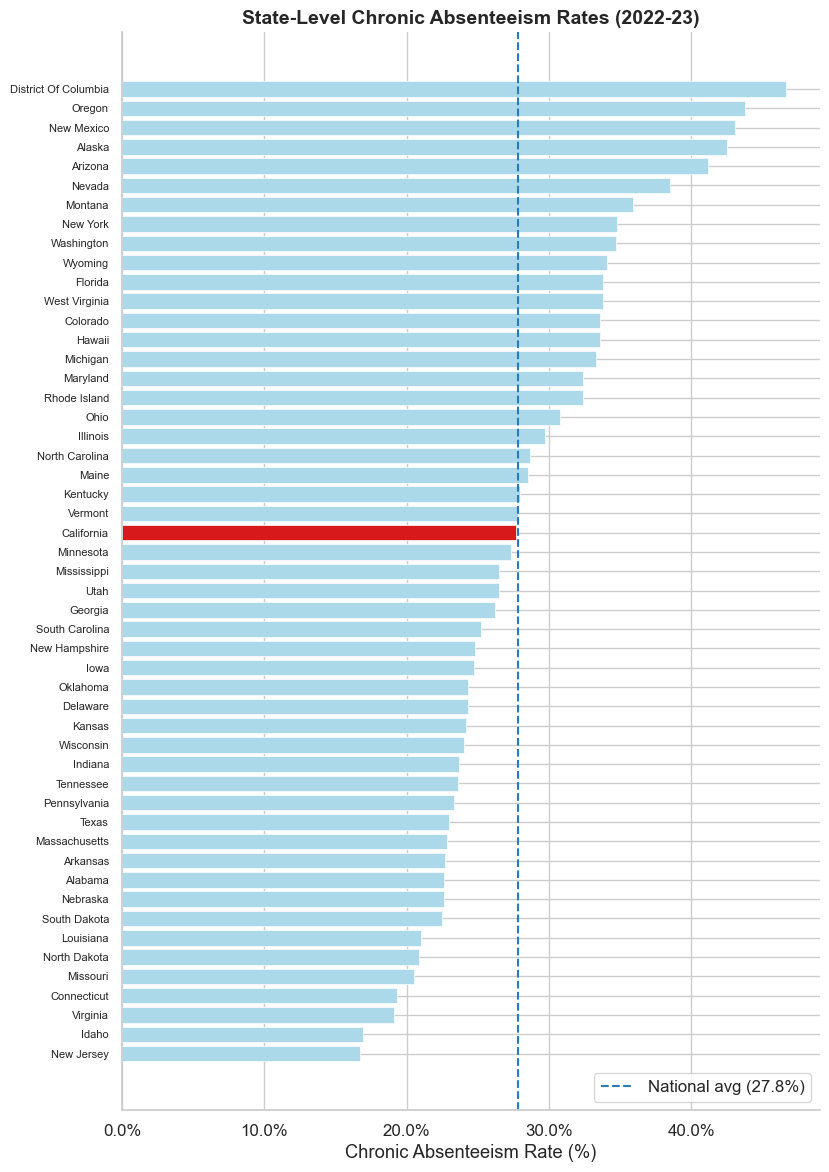

In [5]:
# --- Chart 2: Horizontal bar chart of all states ---
exclude = ['UNITED STATES', 'BUREAU OF INDIAN EDUCATION', 'PUERTO RICO']
s22 = (pct[(pct['School Year'] == '2022-2023') & (~pct['State'].isin(exclude))]
       .dropna(subset=['pct'])
       .sort_values('pct'))

fig, ax = plt.subplots(figsize=(9, 14))
colors = ['#d7191c' if s == 'CALIFORNIA' else '#abd9e9' for s in s22['State']]
bars = ax.barh(s22['State'].str.title(), s22['pct'], color=colors, edgecolor='white', linewidth=0.5)

# National average line
nat_avg = pct[(pct['School Year']=='2022-2023') & (pct['State']=='UNITED STATES')]['pct'].values[0]
ax.axvline(nat_avg, color='#2c7bb6', linestyle='--', linewidth=1.5, label=f'National avg ({nat_avg:.1f}%)')
ax.set_xlabel('Chronic Absenteeism Rate (%)')
ax.set_title('State-Level Chronic Absenteeism Rates (2022-23)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='y', labelsize=8)
sns.despine()
savefig(fig, 'fig2_state_bar_chart')
plt.show()

## 4 — Regional Comparison

Saved ../reports/figures/fig3_regional_boxplot.png


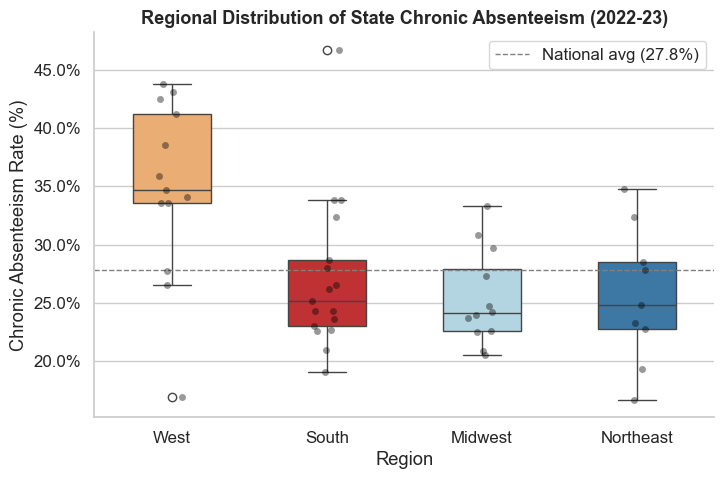

In [6]:
regions = {
    'West': ['ALASKA','ARIZONA','CALIFORNIA','COLORADO','HAWAII','IDAHO','MONTANA',
             'NEVADA','NEW MEXICO','OREGON','UTAH','WASHINGTON','WYOMING'],
    'South': ['ALABAMA','ARKANSAS','DELAWARE','FLORIDA','GEORGIA','KENTUCKY','LOUISIANA',
              'MARYLAND','MISSISSIPPI','NORTH CAROLINA','OKLAHOMA','SOUTH CAROLINA',
              'TENNESSEE','TEXAS','VIRGINIA','WEST VIRGINIA','DISTRICT OF COLUMBIA'],
    'Northeast': ['CONNECTICUT','MAINE','MASSACHUSETTS','NEW HAMPSHIRE','NEW JERSEY',
                  'NEW YORK','PENNSYLVANIA','RHODE ISLAND','VERMONT'],
    'Midwest': ['ILLINOIS','INDIANA','IOWA','KANSAS','MICHIGAN','MINNESOTA','MISSOURI',
                'NEBRASKA','NORTH DAKOTA','OHIO','SOUTH DAKOTA','WISCONSIN'],
}

s22_full = pct[(pct['School Year']=='2022-2023')].set_index('State')
region_data = []
for rname, states in regions.items():
    sub = s22_full.loc[s22_full.index.isin(states)].dropna(subset=['pct'])
    weighted = 100 * sub['Numerator'].sum() / sub['Denominator'].sum()
    for _, row in sub.iterrows():
        region_data.append({'Region': rname, 'State': row.name, 'pct': row['pct']})

rdf = pd.DataFrame(region_data)

# --- Chart 3: Box plot by region ---
fig, ax = plt.subplots(figsize=(8, 5))
order = ['West', 'South', 'Midwest', 'Northeast']
region_colors = {'West':'#fdae61','South':'#d7191c','Midwest':'#abd9e9','Northeast':'#2c7bb6'}
sns.boxplot(data=rdf, x='Region', y='pct', order=order, palette=region_colors, width=0.5, ax=ax)
sns.stripplot(data=rdf, x='Region', y='pct', order=order, color='black', alpha=0.4, size=5, ax=ax)
ax.axhline(nat_avg, color='grey', linestyle='--', linewidth=1, label=f'National avg ({nat_avg:.1f}%)')
ax.set_ylabel('Chronic Absenteeism Rate (%)')
ax.set_title('Regional Distribution of State Chronic Absenteeism (2022-23)', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
savefig(fig, 'fig3_regional_boxplot')
plt.show()

## 5 — National Subgroup Composition

Saved ../reports/figures/fig4_national_race_composition.png


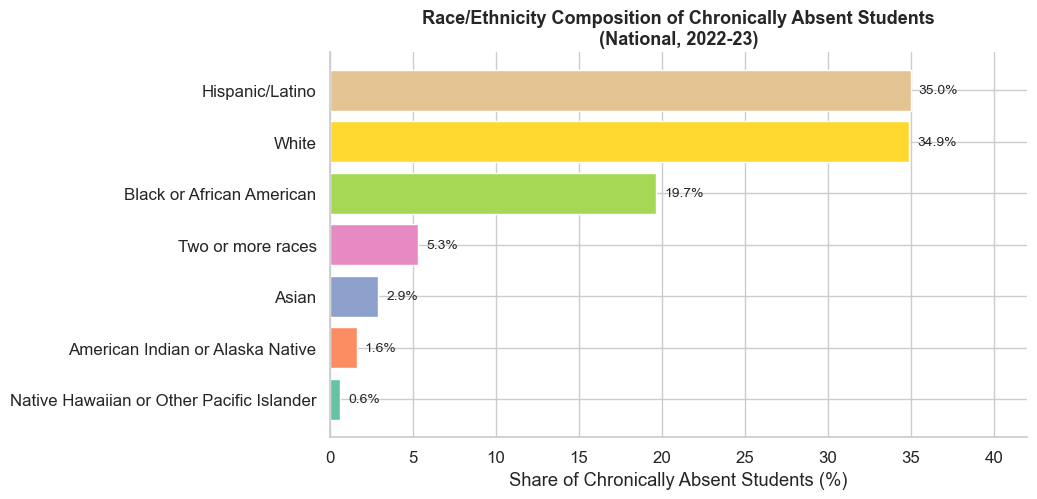

In [7]:
# State-level counts, no gender split, 2022-23
c22 = counts[(counts['School Year']=='2022-2023') &
             counts['NCES LEA ID'].isna() &
             counts['Characteristics'].isna()]

all_chronic = c22[c22['Subgroup']=='All Students in SEA']['Value'].sum()

# Race/ethnicity subgroups
race_groups = ['Hispanic/Latino','White','Black or African American',
               'Two or more races','Asian',
               'American Indian or Alaska Native',
               'Native Hawaiian or Other Pacific Islander']
race_vals = {sg: c22[c22['Subgroup']==sg]['Value'].sum() for sg in race_groups}
race_df = pd.DataFrame({'Subgroup': race_groups,
                         'Count': [race_vals[g] for g in race_groups]})
race_df['Pct'] = 100 * race_df['Count'] / race_df['Count'].sum()
race_df = race_df.sort_values('Count', ascending=True)

# --- Chart 4: Race/ethnicity composition ---
fig, ax = plt.subplots(figsize=(9, 5))
colors_race = sns.color_palette('Set2', len(race_df))
bars = ax.barh(race_df['Subgroup'], race_df['Pct'], color=colors_race, edgecolor='white')
for bar, pct_val in zip(bars, race_df['Pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct_val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Share of Chronically Absent Students (%)')
ax.set_title('Race/Ethnicity Composition of Chronically Absent Students\n(National, 2022-23)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 42)
sns.despine()
savefig(fig, 'fig4_national_race_composition')
plt.show()

Saved ../reports/figures/fig5_national_special_populations.png


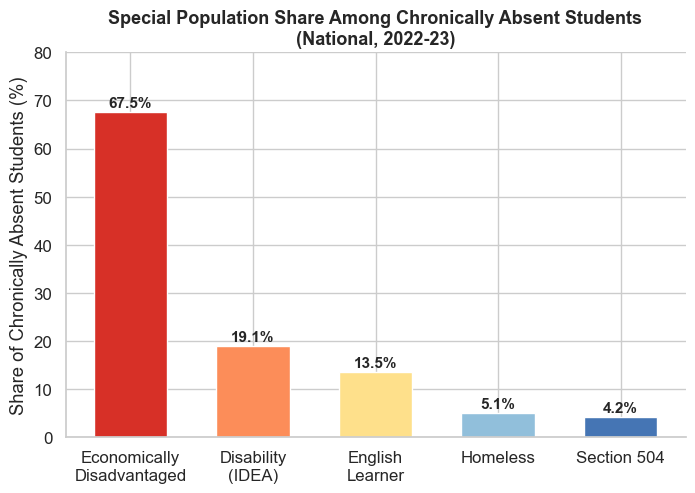

In [8]:
# --- Chart 5: Special-population share (stacked / grouped) ---
special_groups = [
    ('Economically\nDisadvantaged', 'Economically Disadvantaged'),
    ('Disability\n(IDEA)', 'Children with one or more disabilities (IDEA)'),
    ('English\nLearner', 'English Learner'),
    ('Homeless', 'Homeless'),
    ('Section 504', 'Section 504 Disability Status'),
]
sp_labels = [s[0] for s in special_groups]
sp_pcts = [100 * c22[c22['Subgroup']==s[1]]['Value'].sum() / all_chronic for s in special_groups]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sp_labels, sp_pcts, color=['#d73027','#fc8d59','#fee08b','#91bfdb','#4575b4'],
              edgecolor='white', width=0.6)
for bar, v in zip(bars, sp_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Share of Chronically Absent Students (%)')
ax.set_title('Special Population Share Among Chronically Absent Students\n(National, 2022-23)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 80)
sns.despine()
savefig(fig, 'fig5_national_special_populations')
plt.show()

## 6 — OUSD Demographic Patterns

Saved ../reports/figures/fig6_ousd_yearly_trend.png


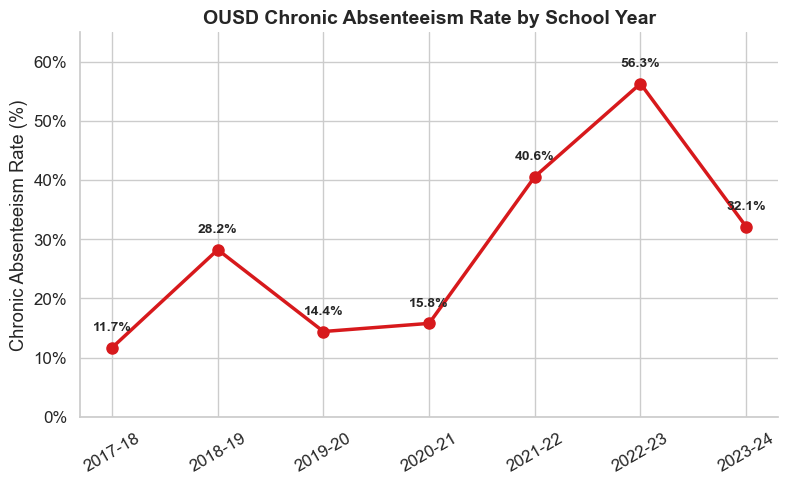

In [9]:
# OUSD chronic rate by year (full series)
ousd_by_year = (att.groupby('school_year').agg(
    rate=('chronic_absent','mean'),
    n=('chronic_absent','size'))
    .sort_index())
ousd_by_year['rate'] *= 100

# --- Chart 6: OUSD yearly trend ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ousd_by_year.index, ousd_by_year['rate'], marker='o', markersize=8,
        linewidth=2.5, color='#d7191c')
for i, (yr, row) in enumerate(ousd_by_year.iterrows()):
    ax.annotate(f'{row["rate"]:.1f}%', (yr, row['rate']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Chronic Absenteeism Rate (%)')
ax.set_title('OUSD Chronic Absenteeism Rate by School Year', fontsize=14, fontweight='bold')
ax.set_ylim(0, 65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30)
sns.despine()
savefig(fig, 'fig6_ousd_yearly_trend')
plt.show()

Saved ../reports/figures/fig7_ousd_ethnicity.png


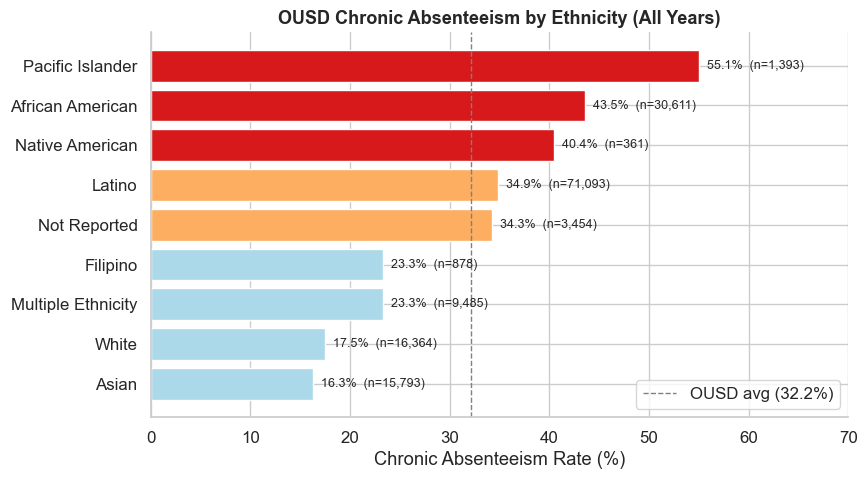

In [10]:
# --- Chart 7: OUSD chronic rate by ethnicity ---
eth_rates = (att.groupby('Eth')['chronic_absent'].agg(['mean','count'])
             .rename(columns={'mean':'rate','count':'n'}))
eth_rates['rate'] *= 100
eth_rates = eth_rates[eth_rates['n'] >= 300].sort_values('rate')

fig, ax = plt.subplots(figsize=(9, 5))
colors_eth = ['#d7191c' if r >= 40 else '#fdae61' if r >= 30 else '#abd9e9'
              for r in eth_rates['rate']]
bars = ax.barh(eth_rates.index, eth_rates['rate'], color=colors_eth, edgecolor='white')
for bar, (_, row) in zip(bars, eth_rates.iterrows()):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f'{row["rate"]:.1f}%  (n={int(row["n"]):,})', va='center', fontsize=9)

overall = 100 * att['chronic_absent'].mean()
ax.axvline(overall, color='grey', linestyle='--', linewidth=1, label=f'OUSD avg ({overall:.1f}%)')
ax.set_xlabel('Chronic Absenteeism Rate (%)')
ax.set_title('OUSD Chronic Absenteeism by Ethnicity (All Years)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 70)
sns.despine()
savefig(fig, 'fig7_ousd_ethnicity')
plt.show()

Saved ../reports/figures/fig8_ousd_sed_sped.png


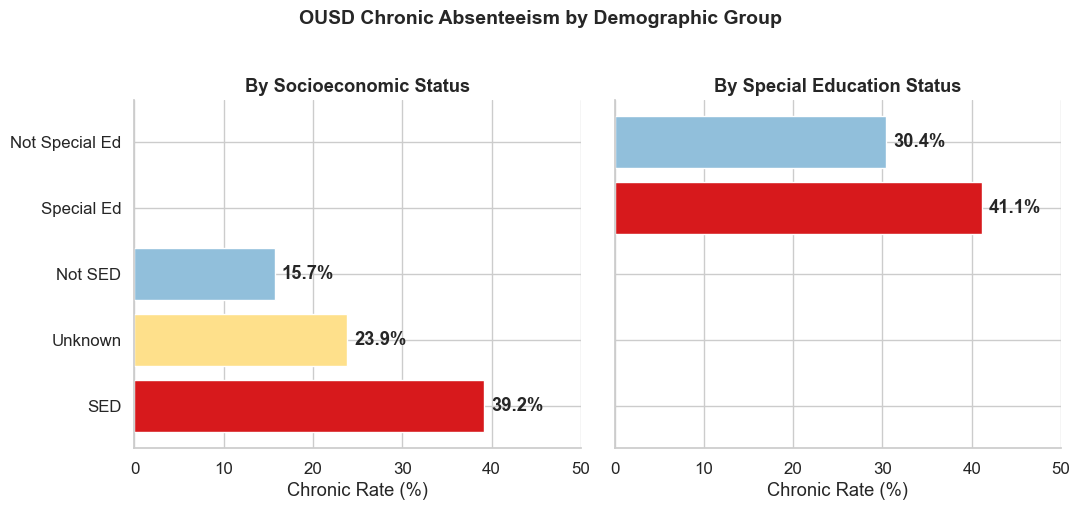

In [11]:
# --- Chart 8: OUSD chronic rate by SED and SpEd (grouped bar) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# SED
sed_rates = att.groupby('SED')['chronic_absent'].mean().mul(100)
sed_rates = sed_rates.reindex(['SED','Unknown','Not SED'])
axes[0].barh(sed_rates.index, sed_rates.values,
             color=['#d7191c','#fee08b','#91bfdb'], edgecolor='white')
for i, (lbl, v) in enumerate(sed_rates.items()):
    axes[0].text(v + 0.8, i, f'{v:.1f}%', va='center', fontweight='bold')
axes[0].set_xlabel('Chronic Rate (%)')
axes[0].set_title('By Socioeconomic Status', fontweight='bold')

# SpEd
sped_rates = att.groupby('SpEd')['chronic_absent'].mean().mul(100)
sped_rates = sped_rates.reindex(['Special Ed','Not Special Ed'])
axes[1].barh(sped_rates.index, sped_rates.values,
             color=['#d7191c','#91bfdb'], edgecolor='white')
for i, (lbl, v) in enumerate(sped_rates.items()):
    axes[1].text(v + 0.8, i+3, f'{v:.1f}%', va='center', fontweight='bold')
axes[1].set_xlabel('Chronic Rate (%)')
axes[1].set_title('By Special Education Status', fontweight='bold')

fig.suptitle('OUSD Chronic Absenteeism by Demographic Group', fontsize=14, fontweight='bold', y=1.02)
for a in axes:
    a.set_xlim(0, 50)
    sns.despine(ax=a)
plt.tight_layout()
savefig(fig, 'fig8_ousd_sed_sped')
plt.show()

## 7 — Grade-Level Patterns

Saved ../reports/figures/fig9_ousd_grade_level.png


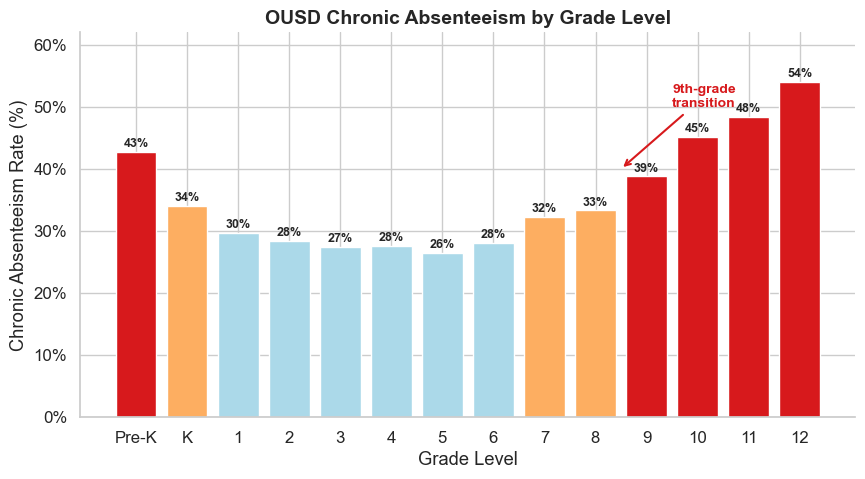

In [12]:
# --- Chart 9: Chronic rate by grade level ---
grade_rates = (att.groupby('Grade')['chronic_absent'].agg(['mean','count'])
               .rename(columns={'mean':'rate','count':'n'}))
grade_rates['rate'] *= 100
grade_rates = grade_rates[grade_rates['n'] >= 100]

labels = {-1:'Pre-K', 0:'K', 1:'1', 2:'2', 3:'3', 4:'4', 5:'5',
          6:'6', 7:'7', 8:'8', 9:'9', 10:'10', 11:'11', 12:'12'}
grade_rates['label'] = grade_rates.index.map(labels)

fig, ax = plt.subplots(figsize=(10, 5))
colors_grade = ['#d7191c' if g in [-1, 9, 10, 11, 12] else
                '#fdae61' if g in [0, 7, 8] else '#abd9e9'
                for g in grade_rates.index]
bars = ax.bar(grade_rates['label'], grade_rates['rate'], color=colors_grade, edgecolor='white')
for bar, v in zip(bars, grade_rates['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

# Annotate the 9th grade transition
ax.annotate('9th-grade\ntransition', xy=(9.5, 40), xytext=(10.5, 50),
            fontsize=10, color='#d7191c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.5))

ax.set_xlabel('Grade Level')
ax.set_ylabel('Chronic Absenteeism Rate (%)')
ax.set_title('OUSD Chronic Absenteeism by Grade Level', fontsize=14, fontweight='bold')
ax.set_ylim(0, 62)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
savefig(fig, 'fig9_ousd_grade_level')
plt.show()

## 8 — Prior-Year Behavioral Early Signals (OUSD)

In [13]:
# Build lagged features
att_sorted = att.sort_values(['ANON_ID', 'year'])
att_sorted['prev_att_rate'] = att_sorted.groupby('ANON_ID')['AttRate'].shift(1)
att_sorted['prev_chronic'] = att_sorted.groupby('ANON_ID')['chronic_absent'].shift(1)
att_sorted['prev_susp'] = att_sorted.groupby('ANON_ID')['Susp'].shift(1)
att_sorted['prev_gpa'] = att_sorted.groupby('ANON_ID')['CurrWeightedTotGPA'].shift(1)

has_prior = att_sorted.dropna(subset=['prev_att_rate', 'chronic_absent']).copy()
print(f'Student-year transitions with prior data: {len(has_prior):,}')

Student-year transitions with prior data: 113,081


Saved ../reports/figures/fig10_prior_attendance_signal.png


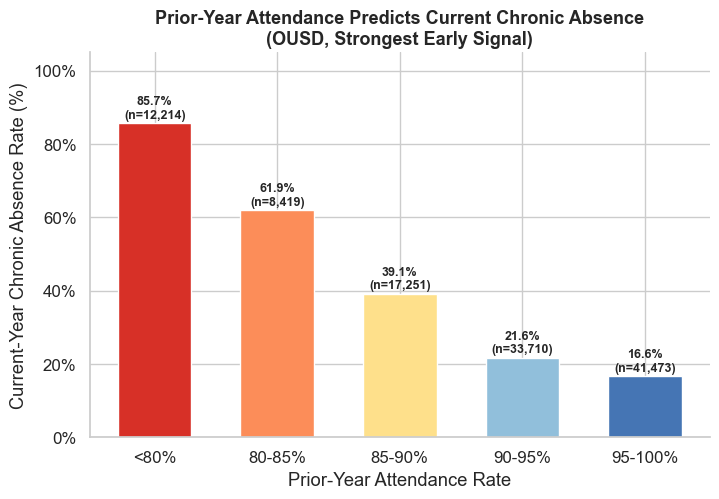

In [14]:
# --- Chart 10: Prior-year attendance → current chronic rate (dose-response) ---
has_prior['att_bucket'] = pd.cut(has_prior['prev_att_rate'],
                                  bins=[0, 0.80, 0.85, 0.90, 0.95, 1.001],
                                  labels=['<80%','80-85%','85-90%','90-95%','95-100%'])
bucket_rates = has_prior.groupby('att_bucket', observed=True)['chronic_absent'].agg(['mean','count'])
bucket_rates['mean'] *= 100

fig, ax = plt.subplots(figsize=(8, 5))
gradient = ['#d73027','#fc8d59','#fee08b','#91bfdb','#4575b4']
bars = ax.bar(bucket_rates.index, bucket_rates['mean'], color=gradient, edgecolor='white', width=0.6)
for bar, (_, row) in zip(bars, bucket_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{row["mean"]:.1f}%\n(n={int(row["count"]):,})',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Prior-Year Attendance Rate')
ax.set_ylabel('Current-Year Chronic Absence Rate (%)')
ax.set_title('Prior-Year Attendance Predicts Current Chronic Absence\n(OUSD, Strongest Early Signal)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
savefig(fig, 'fig10_prior_attendance_signal')
plt.show()

Saved ../reports/figures/fig11_transition_matrix.png


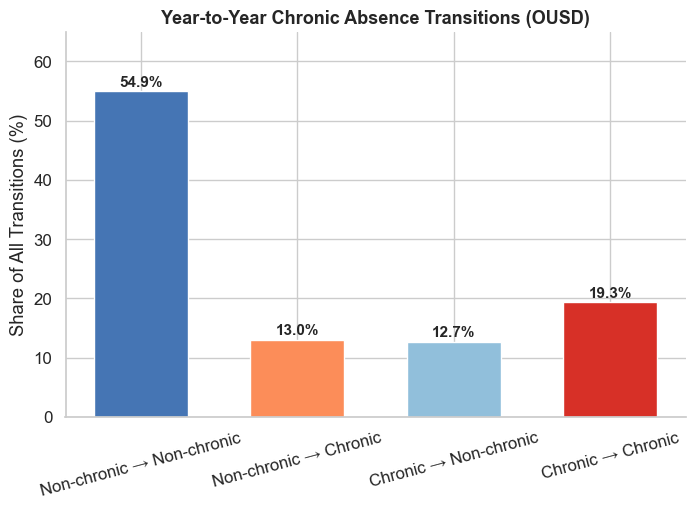

In [15]:
# --- Chart 11: Chronic status transition (Sankey-like grouped bar) ---
trans = has_prior.dropna(subset=['prev_chronic'])
ct = pd.crosstab(trans['prev_chronic'], trans['chronic_absent'], normalize='all') * 100

labels_t = ['Non-chronic → Non-chronic', 'Non-chronic → Chronic',
            'Chronic → Non-chronic', 'Chronic → Chronic']
values_t = [ct.loc[0.0, 0.0], ct.loc[0.0, 1.0], ct.loc[1.0, 0.0], ct.loc[1.0, 1.0]]
colors_t = ['#4575b4', '#fc8d59', '#91bfdb', '#d73027']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_t, values_t, color=colors_t, edgecolor='white', width=0.6)
for bar, v in zip(bars, values_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Share of All Transitions (%)')
ax.set_title('Year-to-Year Chronic Absence Transitions (OUSD)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 65)
plt.xticks(rotation=15)
sns.despine()
savefig(fig, 'fig11_transition_matrix')
plt.show()

Saved ../reports/figures/fig12_prior_gpa_signal.png


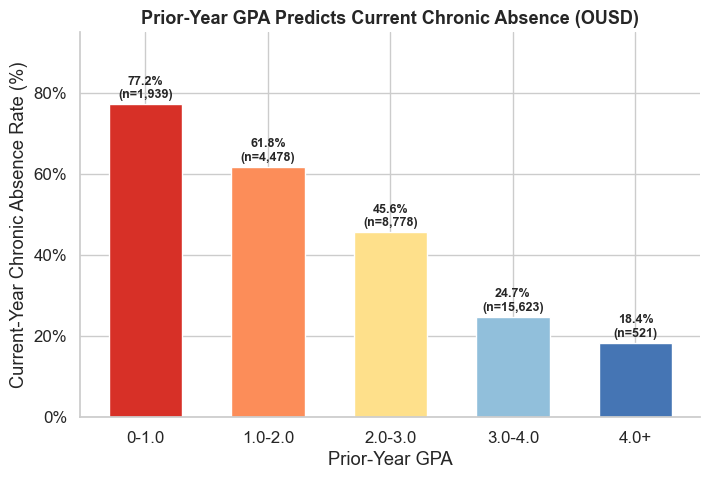

In [16]:
# --- Chart 12: Prior GPA → chronic rate ---
gpa_data = has_prior.dropna(subset=['prev_gpa']).copy()
gpa_data['gpa_bucket'] = pd.cut(gpa_data['prev_gpa'],
                                 bins=[0, 1.0, 2.0, 3.0, 4.0, 5.0],
                                 labels=['0-1.0','1.0-2.0','2.0-3.0','3.0-4.0','4.0+'])
gpa_rates = gpa_data.groupby('gpa_bucket', observed=True)['chronic_absent'].agg(['mean','count'])
gpa_rates['mean'] *= 100

fig, ax = plt.subplots(figsize=(8, 5))
gradient_gpa = ['#d73027','#fc8d59','#fee08b','#91bfdb','#4575b4']
bars = ax.bar(gpa_rates.index, gpa_rates['mean'], color=gradient_gpa, edgecolor='white', width=0.6)
for bar, (_, row) in zip(bars, gpa_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{row["mean"]:.1f}%\n(n={int(row["count"]):,})',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Prior-Year GPA')
ax.set_ylabel('Current-Year Chronic Absence Rate (%)')
ax.set_title('Prior-Year GPA Predicts Current Chronic Absence (OUSD)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
savefig(fig, 'fig12_prior_gpa_signal')
plt.show()

Saved ../reports/figures/fig13_prior_suspension_signal.png


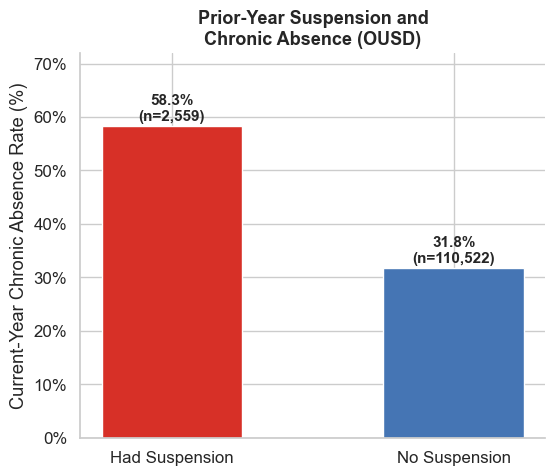

In [17]:
# --- Chart 13: Prior suspension → chronic rate ---
susp_data = has_prior.dropna(subset=['prev_susp']).copy()
susp_data['had_susp'] = susp_data['prev_susp'].apply(lambda x: 'Had Suspension' if x > 0 else 'No Suspension')
susp_rates = susp_data.groupby('had_susp')['chronic_absent'].agg(['mean','count'])
susp_rates['mean'] *= 100
susp_rates = susp_rates.reindex(['Had Suspension','No Suspension'])

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(susp_rates.index, susp_rates['mean'], color=['#d73027','#4575b4'],
              edgecolor='white', width=0.5)
for bar, (_, row) in zip(bars, susp_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{row["mean"]:.1f}%\n(n={int(row["count"]):,})',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Current-Year Chronic Absence Rate (%)')
ax.set_title('Prior-Year Suspension and\nChronic Absence (OUSD)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 72)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
savefig(fig, 'fig13_prior_suspension_signal')
plt.show()

## 9 — Neighborhood-Level Signals

Saved ../reports/figures/fig14_neighborhood_comparison.png


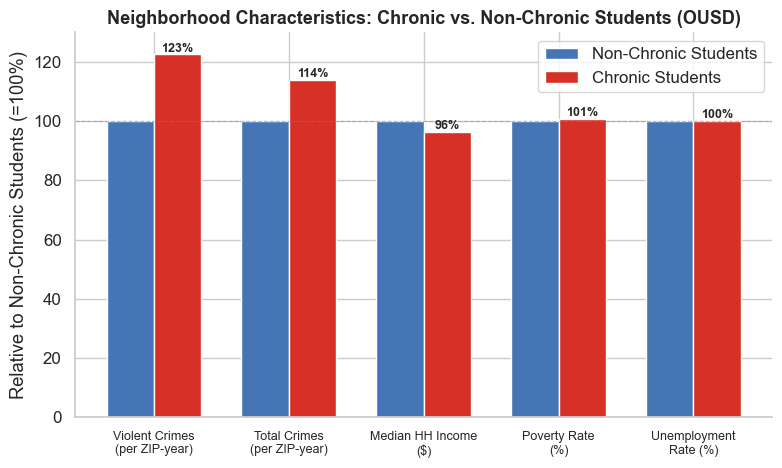

In [18]:
# --- Chart 14: Neighborhood factor comparison (chronic vs non-chronic) ---
neigh_cols = ['violent_crimes', 'total_crimes', 'median_household_income',
              'poverty_rate_pct', 'unemployment_rate_pct']
neigh_labels = ['Violent Crimes\n(per ZIP-year)', 'Total Crimes\n(per ZIP-year)',
                'Median HH Income\n($)', 'Poverty Rate\n(%)', 'Unemployment\nRate (%)']

chronic_means = []
non_chronic_means = []
for col in neigh_cols:
    sub = att.dropna(subset=[col, 'chronic_absent'])
    chronic_means.append(sub[sub['chronic_absent']==1][col].mean())
    non_chronic_means.append(sub[sub['chronic_absent']==0][col].mean())

# Normalize to non-chronic = 100% for comparison
ratios = [c/nc * 100 for c, nc in zip(chronic_means, non_chronic_means)]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(neigh_labels))
width = 0.35
ax.bar([i - width/2 for i in x], [100]*len(x), width, label='Non-Chronic Students',
       color='#4575b4', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], ratios, width, label='Chronic Students',
               color='#d73027', edgecolor='white')

for bar, r in zip(bars2, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{r:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(neigh_labels, fontsize=9)
ax.set_ylabel('Relative to Non-Chronic Students (=100%)')
ax.set_title('Neighborhood Characteristics: Chronic vs. Non-Chronic Students (OUSD)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 130)
sns.despine()
savefig(fig, 'fig14_neighborhood_comparison')
plt.show()

## 10 — Summary: Early-Signal Strength Ranking

Saved ../reports/figures/fig15_signal_strength_ranking.png


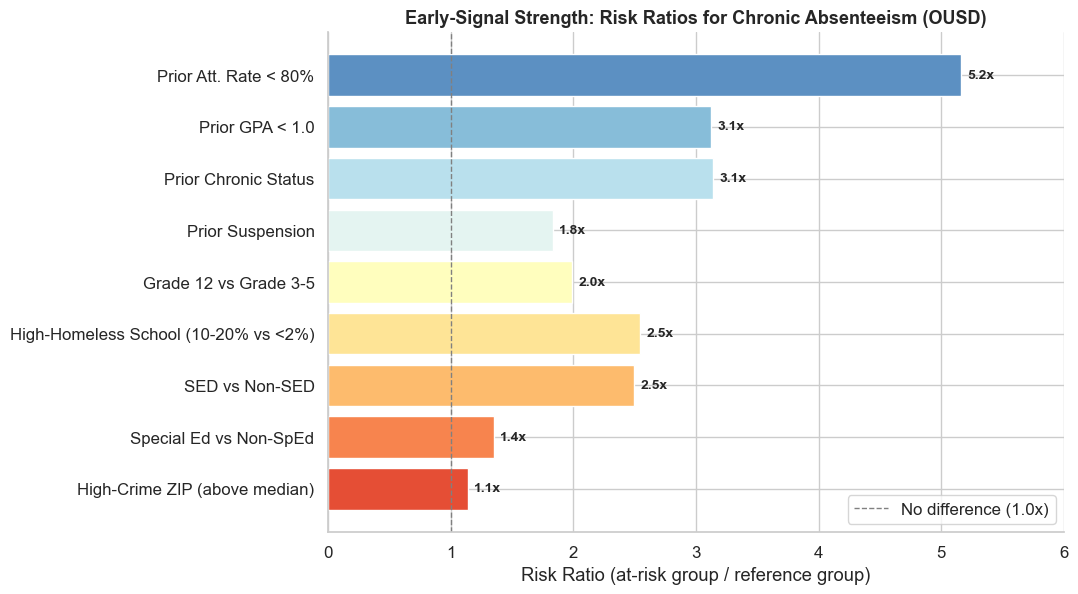

In [19]:
# --- Chart 15: Combined early-signal summary (risk ratio chart) ---
signals = [
    ('Prior Att. Rate < 80%', 85.7, 16.6),
    ('Prior GPA < 1.0', 77.2, 24.7),
    ('Prior Chronic Status', 60.3, 19.2),
    ('Prior Suspension', 58.3, 31.8),
    ('Grade 12 vs Grade 3-5', 54.0, 27.1),
    ('High-Homeless School (10-20% vs <2%)', 48.6, 19.1),
    ('SED vs Non-SED', 39.2, 15.7),
    ('Special Ed vs Non-SpEd', 41.1, 30.4),
    ('High-Crime ZIP (above median)', 114*32.2/100, 32.2),  # approximate
]

sig_labels = [s[0] for s in signals]
risk_ratios = [s[1]/s[2] for s in signals]

fig, ax = plt.subplots(figsize=(9.5, 6.5))
y_pos = range(len(sig_labels))
colors_sig = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(signals)))
bars = ax.barh(sig_labels[::-1], risk_ratios[::-1], color=colors_sig[::-1], edgecolor='white')
for bar, rr in zip(bars, risk_ratios[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rr:.1f}x', va='center', fontsize=10, fontweight='bold')

ax.axvline(1.0, color='grey', linestyle='--', linewidth=1, label='No difference (1.0x)')
ax.set_xlabel('Risk Ratio (at-risk group / reference group)')
ax.set_title('Early-Signal Strength: Risk Ratios for Chronic Absenteeism (OUSD)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 6)
sns.despine()
savefig(fig, 'fig15_signal_strength_ranking')
plt.show()


Saved ../reports/figures/fig16_yoy_change.png


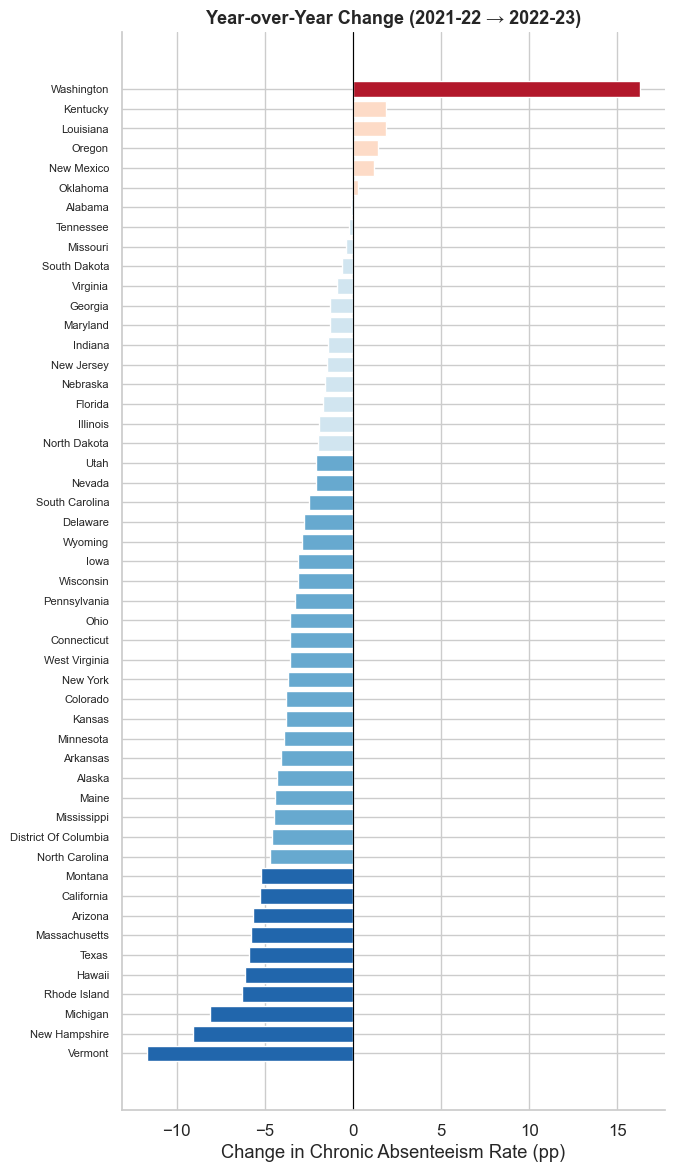

In [20]:
# --- Chart 16: Year-over-year change heatmap (states) ---
pct_wide = pct[~pct['State'].isin(['UNITED STATES','BUREAU OF INDIAN EDUCATION','PUERTO RICO'])].copy()
pct_pivot = pct_wide.pivot(index='State', columns='School Year', values='pct')
pct_pivot = pct_pivot.dropna(subset=['2021-2022','2022-2023'])
pct_pivot['Change'] = pct_pivot['2022-2023'] - pct_pivot['2021-2022']
pct_pivot = pct_pivot.sort_values('Change')

fig, ax = plt.subplots(figsize=(7, 14))
colors_change = ['#2166ac' if c < -5 else '#67a9cf' if c < -2 else '#d1e5f0' if c < 0
                 else '#fddbc7' if c < 2 else '#ef8a62' if c < 5 else '#b2182b'
                 for c in pct_pivot['Change']]
bars = ax.barh(pct_pivot.index.str.title(), pct_pivot['Change'], color=colors_change, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in Chronic Absenteeism Rate (pp)')
ax.set_title('Year-over-Year Change (2021-22 → 2022-23)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
sns.despine()
savefig(fig, 'fig16_yoy_change')
plt.show()

## 11 — Homeless Student Enrollment (School-Level Signal)

Using CDE Homeless Student Enrollment files joined to OUSD schools, we examine (a) how OUSD's school-level homeless enrollment has trended and (b) whether attending a school with higher homeless enrollment predicts individual chronic absenteeism.


In [21]:
# --- Load homeless data & join to student-year records ---
import re

def _norm_name(s):
    if pd.isna(s): return s
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    s = re.sub(r'\b(school|the)\b', ' ', s)
    s = re.sub(r'\b[a-z]\b', ' ', s)  # drop middle initials
    return re.sub(r'\s+', ' ', s).strip()

homeless = pd.read_csv('../data/ousd_homeless_by_school.csv')
homeless['_sn'] = homeless['school_name'].map(_norm_name)
att['_sn'] = att['SiteName'].map(_norm_name)

att_h = att.merge(
    homeless[['_sn', 'year', 'homeless_rate', 'homeless_n', 'enrollment']],
    left_on=['_sn', 'school_year'], right_on=['_sn', 'year'],
    how='left', suffixes=('', '_h')
)
matched = att_h['homeless_rate'].notna().sum()
print(f'Matched {matched:,} / {len(att_h):,} student-years ({matched/len(att_h):.1%}) to a school homeless rate')

# District-level homeless enrollment trend
dist_trend = (homeless.groupby('year')
              .apply(lambda d: d['homeless_n'].sum() / d['enrollment'].sum() * 100)
              .rename('homeless_pct'))
print('\nOUSD district-wide homeless enrollment rate by year:')
print(dist_trend.round(2))


Matched 102,221 / 149,432 student-years (68.4%) to a school homeless rate

OUSD district-wide homeless enrollment rate by year:
year
2019-20    2.37
2020-21    2.02
2021-22    3.34
2022-23    4.29
2023-24    5.67
2024-25    5.51
Name: homeless_pct, dtype: float64


Saved ../reports/figures/fig17_ousd_homeless_trend.png


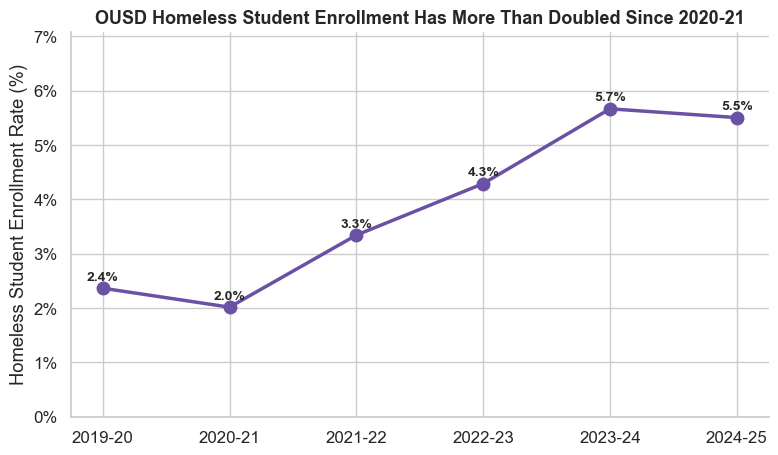

In [22]:
# --- Chart 17: OUSD homeless enrollment trend ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dist_trend.index, dist_trend.values, marker='o', linewidth=2.5,
        markersize=9, color='#6a51a3')
for x, y in zip(dist_trend.index, dist_trend.values):
    ax.text(x, y + 0.15, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Homeless Student Enrollment Rate (%)')
ax.set_title('OUSD Homeless Student Enrollment Has More Than Doubled Since 2020-21',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(dist_trend.values) * 1.25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
sns.despine()
savefig(fig, 'fig17_ousd_homeless_trend')
plt.show()


                rate      n
hr_bucket                  
0-2%       19.073271  47522
2-5%       37.283725  28436
5-10%      45.310529  19821
10%+       48.633965   6442


Saved ../reports/figures/fig18_homeless_school_signal.png


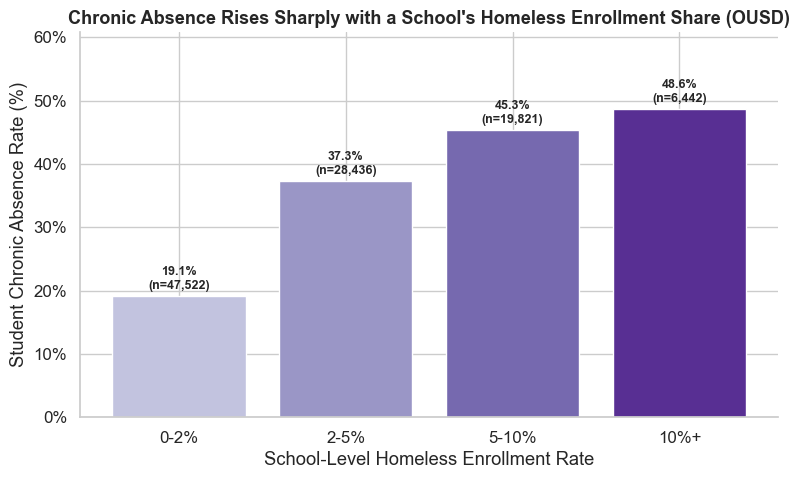


Correlation (school homeless rate vs. student chronic): +0.227
Chronic students attend schools averaging 4.68% homeless enrollment
Non-chronic students attend schools averaging 2.90% homeless enrollment


In [23]:
# --- Chart 18: Student chronic rate by school-level homeless enrollment bucket ---
m = att_h.dropna(subset=['homeless_rate']).copy()
m['hr_bucket'] = pd.cut(m['homeless_rate'],
                        bins=[-0.001, 0.02, 0.05, 0.10, 1.0],
                        labels=['0-2%', '2-5%', '5-10%', '10%+'])
hr_rates = (m.groupby('hr_bucket', observed=True)['chronic_absent']
            .agg(['mean', 'count']).rename(columns={'mean':'rate','count':'n'}))
hr_rates['rate'] *= 100
print(hr_rates)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.Purples(np.linspace(0.35, 0.85, len(hr_rates)))
bars = ax.bar(hr_rates.index.astype(str), hr_rates['rate'], color=colors, edgecolor='white')
for bar, (lbl, row) in zip(bars, hr_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f'{row["rate"]:.1f}%\n(n={int(row["n"]):,})',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('School-Level Homeless Enrollment Rate')
ax.set_ylabel('Student Chronic Absence Rate (%)')
ax.set_title('Chronic Absence Rises Sharply with a School\'s Homeless Enrollment Share (OUSD)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(hr_rates['rate']) * 1.25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
sns.despine()
savefig(fig, 'fig18_homeless_school_signal')
plt.show()

# Correlation summary
corr = m[['homeless_rate','chronic_absent']].corr().iloc[0,1]
chr_mean = m[m['chronic_absent']==1]['homeless_rate'].mean() * 100
non_chr_mean = m[m['chronic_absent']==0]['homeless_rate'].mean() * 100
print(f'\nCorrelation (school homeless rate vs. student chronic): {corr:+.3f}')
print(f'Chronic students attend schools averaging {chr_mean:.2f}% homeless enrollment')
print(f'Non-chronic students attend schools averaging {non_chr_mean:.2f}% homeless enrollment')


## Summary

All 16 figures have been saved to `reports/figures/`. These visualizations support the findings in the **National & Local Early-Signal Landscape Report**:

| Figure | Description |
|--------|-------------|
| Fig 1 | National vs. California vs. OUSD trend comparison |
| Fig 2 | State-level chronic absenteeism bar chart |
| Fig 3 | Regional distribution box plot |
| Fig 4 | National race/ethnicity composition |
| Fig 5 | National special-population shares |
| Fig 6 | OUSD yearly trend (full 7-year series) |
| Fig 7 | OUSD chronic rate by ethnicity |
| Fig 8 | OUSD chronic rate by SED and SpEd status |
| Fig 9 | OUSD chronic rate by grade level |
| Fig 10 | Prior-year attendance → chronic rate (strongest signal) |
| Fig 11 | Year-to-year chronic status transitions |
| Fig 12 | Prior-year GPA → chronic rate |
| Fig 13 | Prior-year suspension → chronic rate |
| Fig 14 | Neighborhood characteristics comparison |
| Fig 15 | Early-signal strength risk-ratio ranking |
| Fig 16 | State year-over-year change (2021-22 → 2022-23) |